----
# Word2Vec
-----

## Notebook Summary

In this notebook, I’ll explore **Word2Vec**, a method used to transform email text into word embeddings. Word embeddings are a numerical representation of words, where words with similar meanings are represented by vectors that are close to each other in the vector space.

This notebook follows a similar layout to the TF-IDF notebook:

1. **Data Loading:** Load the cleaned data from the data folder.

2. **Preparing Text:** Preprocess the text for tokenisation, handling stopwords, and using SpaCy to remove irrelevant words.

3. **Transform Text:** Apply Word2Vec to convert words to embeddings and explore semantic relationships between them.

4. **Evaluate Embeddings:** Use various methods to see how well embeddings capture semantic relationships between selected words.


## Set Up
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import re
import string

import spacy
import gensim
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

## Data Loading
----

In [2]:
emails_df = pd.read_csv('../../data/cleaned_emails.csv', index_col= 0)

In [3]:
# working with subset of data first to assess results
email_subset_df = emails_df[:40_000].copy()

## Preparing Text
-----

### Combine subject and body

In [4]:
# Combining subject and body to better understand context of emails
email_subset_df['all_text'] = email_subset_df['cleaned_subject'] + ' ' + email_subset_df['cleaned_body']

### Removing Employee Names, Dates and Organisations

In [5]:
# load the pre-trained spaCy model for NER
nlp = spacy.load('en_core_web_sm')

def remove_names(text):
    # ensuring all text is of type string
    text = str(text)
    # using model to process email text (subject + body)
    doc = nlp(text)
    # need to reverse order in which entities are removed to avoid disrupting order of text
    #  important as otherwise model will not recognise other entities to be removed
    for e in reversed(doc.ents):
        # to remove words where entity is PERSON, ORG or DATE
        if e.label_ in ("PERSON", "ORG", "DATE",): 
            # remove the entity by slicing the text: 
            #   keep the part before the entity, skip the entity itself and keep the part after it
            text = text[:e.start_char] + text[e.start_char + len(e.text):]

    return text


In [6]:
email_subset_df['all_text'] = email_subset_df['all_text'].apply(remove_names)

## Tokenise Text
-----

In [7]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/simybasra/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [8]:
lemmatizer = WordNetLemmatizer()

In [9]:
def my_tokeniser(email):
    """
    A custom tokeniser to use in TF-IDF Vecotoriser.
    Preprocesses input text and produces tokens.
    """
    email = email.lower()
    email = re.sub(r'\d+','',email)
    listofwords = email.split(' ')
    listoflemm_words = []
    for word in listofwords:  
        if (word != ''):
            lemm_word = lemmatizer.lemmatize(word)
            listoflemm_words.append(lemm_word)

    return listoflemm_words

In [10]:
tokened_emails = []

for email in email_subset_df['all_text']:
    # tokenise the email text using simple_preprocess
    tokens = my_tokeniser(email)
    tokened_emails.append(tokens)



## Vectorise Text using Word2Vec
----

In [ ]:
w2v_model = Word2Vec(
                sentences=tokened_emails,
                vector_size=300,  # size of embeddings, higher values capture more semantics
                window=10,        # setting to 10 to capture more context 
                min_count=15,     # ensure rare words are included 
                workers=4,          
                sg = 1,           # choosing to use Skip-Gram
                seed = 22, 
                epochs = 25
            )

## Assess Embeddings
-----

To assess the quality of the word embeddings, I will focus on these three main things:

**1. Semantic Similiarity Between Embeddings**

- Evaluate how well the embeddings reflect the semantic relationships between words.
- To do this, I will calculate the most similar words to a given word using the embeddings I trained.
- I will also perform some word arithmetic to also assess if the embeddings correctly capture context.

**2. Visualise the Embeddings**

- Reduce the dimensionality of the vecotrs using t-SNE in order to plot embeddings to see if similar words are placed closed to each other.

When choosing which words to evaluate, I thought it best to use insights gathered by TF-IDF to help. I thought this is the best way to find words to evaluate as TF-IDF returns the most important words in the dataset.


---
### Picking words to evaluate
-----


When deciding which words are best to evaluate the embeddings, I thought to look at the results of the LDA. This is as each topic reflects key themes in the data, by selecting words from each topic I can assess embeddings which are representative of key themes in the data. 

The words i will be choosing:

**Topic #1: Finance**

    risk
    market
    cash


**Topic #2: Operations**

    operational
    shipping
    security

**Topic #3: Legal**

    privileged
    evidence
    contract


-----
### 1. Semantic Similarity
-----

#### Using word2Vec's `most_similar`

In [12]:
def semantic_rels(word):
    """
    Description: 
        Finds and returns the top 5 most similar words to a given word based on cosine similarity.  

    Inputs:  
        word (str): The target word for which similar words will be retrieved.  

    Outputs:  
        List of tuples: Each tuple contains a similar word and its cosine similarity score.  
    """

    similar_words = w2v_model.wv.most_similar(word, topn=5)

    return similar_words 

In [13]:
evaluate_words = ['risk', 'market', 'cash', 'operational', 'shipping', 'security', 'privileged', 'evidence', 'contract']

In [14]:
for word in evaluate_words:
    results = semantic_rels(word)
    print('\n*************************************************\n')
    print(f'Words Similar To: {word.upper()}\n')
    for word, sim_score in results:
        print(word)


*************************************************

Words Similar To: RISK

management
operational
liquidityfunding
reporting
sapisc

*************************************************

Words Similar To: MARKET

energy
realtime
price
discussion
power

*************************************************

Words Similar To: CASH

flow
corpect
reftws
michelle
gidlct

*************************************************

Words Similar To: OPERATIONAL

risk
management
operation
assessment
mitigate

*************************************************

Words Similar To: SHIPPING

handling
order
fingerhutcom
item
shipped

*************************************************

Words Similar To: SECURITY

brokerdealer
approver
crapper
enforcement
editing

*************************************************

Words Similar To: PRIVILEGED

confidential
contain
sole
attorneyclient
addressee

*************************************************

Words Similar To: EVIDENCE

enforceable
binding
acceptance
create
hereto


-----
**Comment:**

- For some word, embeddings have done well to map the semantic relationships, such as:  
  - **"Risk"** - management, operational, operation reflecting business and finance operations
  - **"Market"** price, energy, power reflecting the energy trade
  - **"Privileged"** confidential, attorney-client reflecting legal terms
 
- Some words appear unrelated or garbage like:

  - **"Security"** brokerdealer, screener these terms relate more to the finance industry than security
  - **"Evidence"** create, acceptance theses words don't really capture the legal connection

Overall, these results aren't all terrible but the embeddings could be a lot better. These issues may be due to training the word 2 vec model on only a smalll subset of data. Some outputs include garbage-like words like 'gidlct', 'reftws' likely due to remamining noise in the data.

#### Using Word Arithmetics

Word Arithmetics involves using the embeddings in simple mathematical forumlas (like you would use numbers). Doing this, allows us to assess how well the vecotrs reflect semantic relationships between words since words with similar meaning should have similar vectors and be close together.

To test this, we create pairings based on key themes in the data (Finance, Legal, and Operations). For example:

    Risk + Management - Operation: Checks if "risk" and "management" are similar when "operation" is removed.
    Market + Cash - Risk: Tests if "cash" and "market" are tied to finance, without the influence of "risk."
    Shipping + Handling - Security: Assesses if logistics-related words  like "shipping," "handling" change without "security."
    Contract + Privileged - Evidence: Examines how "contract" and "privileged" relate in a legal context, removing "evidence.

In [15]:
word_pairs = [
    (['market', 'security'], ['risk']),
    (['shipping', 'operational'], ['security']),  
    (['contract', 'privileged'], ['evidence']),  
    (['cash', 'market'], ['risk'])  
]


In [16]:
for positive, negative in word_pairs:
    result = w2v_model.wv.most_similar(positive=positive, negative=negative, topn=5)
    print('\n*************************************************\n')
    print(f"{' + '.join(positive)} - {' + '.join(negative)}  = \n")
    display(result)



*************************************************

market + security - risk  = 



[('issued', 0.2847479581832886),
 ('national', 0.27360355854034424),
 ('price', 0.2584315240383148),
 ('sector', 0.2565366327762604),
 ('economy', 0.2544119656085968)]


*************************************************

shipping + operational - security  = 



[('handling', 0.37581413984298706),
 ('crossfunctional', 0.2758132517337799),
 ('delighted', 0.26391756534576416),
 ('risk', 0.25930342078208923),
 ('origination', 0.2535439431667328)]


*************************************************

contract + privileged - evidence  = 



[('confidential', 0.47010236978530884),
 ('proprietary', 0.3891742527484894),
 ('contain', 0.38534054160118103),
 ('sole', 0.353036493062973),
 ('addressee', 0.3453480303287506)]


*************************************************

cash + market - risk  = 



[('price', 0.3757554590702057),
 ('flow', 0.2981143593788147),
 ('corpect', 0.280877023935318),
 ('realtime', 0.2731786370277405),
 ('jnpr', 0.2726233899593353)]

----------
**Comment:**

Results are fairly mixed, but I do think that they show the current word embeddings are rather limited and so more complex ways are needed to create embeddings for this dataset.

**Market + Security - Risk → ['rtm', 'national', 'urged', 'issued', 'economy']**

Words like 'rtm', 'national', 'economy', and 'issued' seem more related to trading or economics rather than "market" or "security." This suggests that the model might not have captured the semantic relationships between "market," "security," and "risk" accurately. Some of these terms like 'rtm' might be noise or acronym-like terms, which don't seem to fit well in the context. Acronyms is something I didn't think about when vleaning data and may have to go back to the data cleaning to address this.

**Shipping + Operational - Security → ['handling', 'risk', 'proliferation', 'underwriting', 'lyon']**

Here, the results are more reasonable. Words like 'handling', 'risk', and 'proliferation' are related to the operations. However, 'lyon' more likely to be a place and has no relevance to operations. 'risk' is also strange, suggesting the embeddings may be mixing up operational and financial contexts.

**Contract + Privileged - Evidence → ['confidential', 'contain', 'estoppel', 'proprietary', 'attorneyclient']**

These results seem quite strong and meaningful. Words like 'confidential', 'attorney-client', and 'proprietary' align well with legal contexts.

**Cash + Market - Risk → ['price', 'rtm', 'flow', 'realtime', 'regular']**

Not bad results, words like 'price', 'flow', and 'realtime' are closely related to trading and finance. However, 'rtm' is a bit of an odd result, it could be another acronym perhaps.

## Visualising Word Embeddings
------

In [17]:
from sklearn.manifold import TSNE

In [18]:
# extending evaluate words as TSNE works best with more words 
evaluate_words.extend(['analysis', 'investment', 'estate', 'asset', 'portfolio', 'revenue', 'equity', 'stock', 'valuation','logistics', 'compliance', 
                       'scheduling', 'handling', 'process', 'efficiency', 'transport', 'warehouse', 'oversight', 'monitoring', 'binding', 'disclosure', 
                       'enforceable', 'affiliate', 'litigation', 'jurisdiction', 'confidentiality', 'regulation', 'liability'
])

In [19]:
# get embeddings from word 2 vec model
embeddings = np.array([w2v_model.wv[word] for word in evaluate_words])

In [20]:
# instantiate TSNE model
tsne = TSNE(random_state = 11, n_iter = 1000, metric = 'cosine', perplexity=35)

In [21]:
# reduce embeddings to 2 dimensions for easy visualisation
embeddings_2d = tsne.fit_transform(embeddings)

/Users/simybasra/anaconda3/envs/email_genie/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


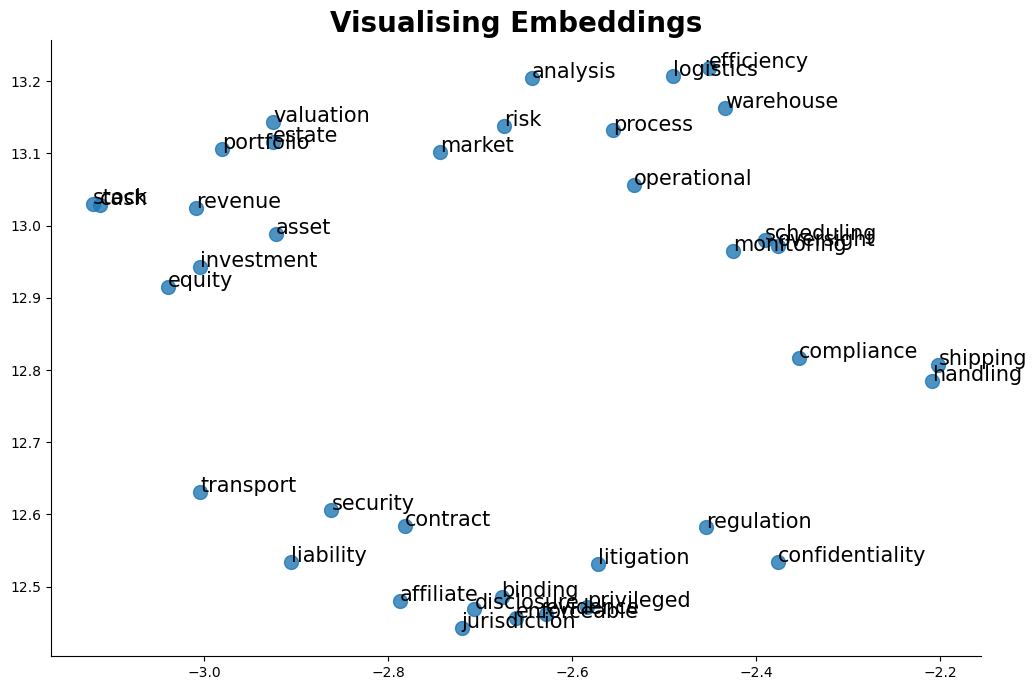

In [22]:
plt.figure(figsize=(12, 8))
plt.scatter(x = embeddings_2d[:,0],y = embeddings_2d[:,1],alpha= 0.8, s= 100) 
# labelling words
for i, word in enumerate(evaluate_words):
    plt.annotate(word, xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=15)

plt.gca().spines[['top', 'right']].set_visible(False)
plt.title('Visualising Embeddings', fontsize=20, fontweight = 'bold')
plt.show()

----
**Comment:**

Results from t-SNE visualisation show there is some slight groupings of embeddings.

For example:

**Financial** terms such as *'stock'*, *'revenue'*, *'investment'*, *'equity'*, and *'cash' *are close to each other, indicating that Word2Vec has captured some semantic relationships between financial terms.

**Operational** terms like *'logistics'*, *'efficiency'*, *'warehouse'*, and *'transport'* also appear relatively close, suggesting that the model recognises their similarity in meaning.

**Legal** terms including *'contract'*, *'litigation'*, *'jurisdiction'*, *'liability'*, *'binding'*, and *'confidentiality'* show some grouping suggesting the model understands these words are related to each other.

However, the groupings are not well-defined, with some overlapping areas and some terms appearing far from their expected grouping such as *'risk'* and *'market'*. This suggests that while Word2Vec captures general relationships, it still is missing some context and highlights the issue in struggling with words that have multiple meanings. 

## Summary
----

Using Word2Vec to create embeddings has given an insight into how embeddings can capture relationships between words, this is something traditional methods like TF-IDF cannot do. Despite training the Word2Vec on only a subset of the data, the model performed better than I expected especially in its ability to partially group related terms.

However, for tasks such as clustering and classification, I think ita best to move to more sophisticated methods of creating embeddings. Transformer-based models like BERT not only capture deeper semantic relationships but can also capture more context in text. In the following notebook, I experiment with BERT and compare its perforance to Word2Vec.